In [5]:
# default imports
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# brixs imports
import sys
sys.path.append('brixs/')
import brixs as br
import brixs.beamlines.i21 as i21
import brixs.addons.fitting

# matplotlib backend (use widget on jupyter notebook, or qt5 elsewhere)
if br.is_jupyter:
    %matplotlib widget
else:
    %matplotlib qt5
    br.settings.FIGURE_POSITION = (1500, 1400)  # home
    br.settings.FIGURE_POSITION = (60, 140) 
    # br.get_window_position()

# Enable interactive mode
plt.ion()

# Constrained layout is on by default to make figures larger
br.settings.FIGURE_CONSTRAINED_LAYOUT = True

# folderpaths
proposal = 'cm44171-4'
TOP   = Path(r'/dls/i21/data/2026/' + proposal + r'/processing')
DATA  = TOP/'..'
TMP   = TOP/'tmp'
OUT   = TOP/'out'
STORE = TOP/'store'

# finder settings
br.finder.folderpath = TMP
br.finder.verbose    = True
br.finder.search_on  = True
br.finder.save_on    = True

# default i21 parameters
i21.settings.FOLDERPATH = DATA

# 0. Calculate gross slope

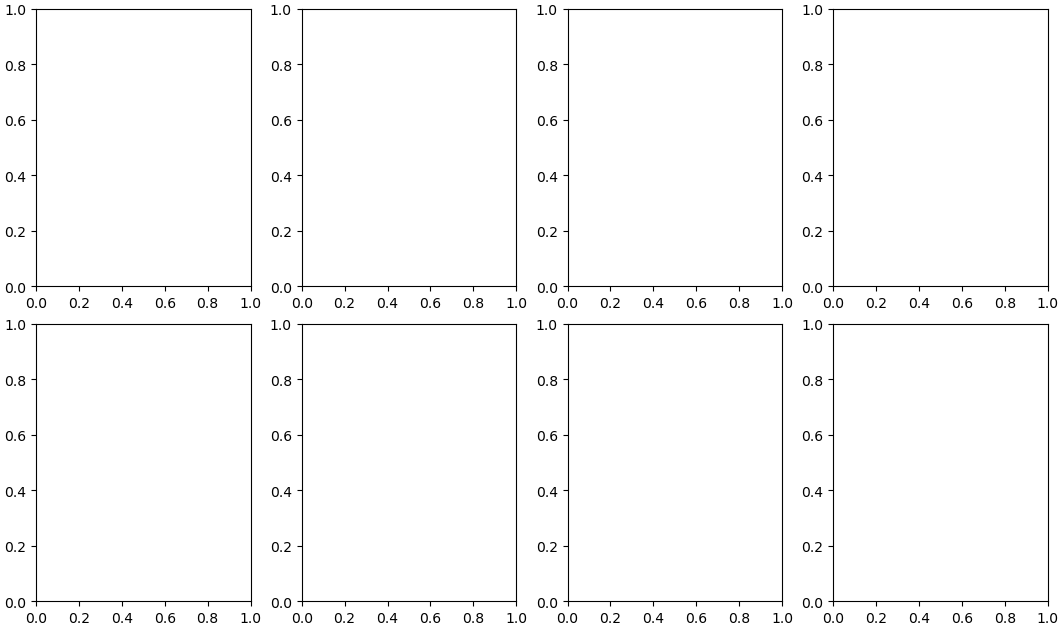

Output()

slope = -0.020217327028364217


In [2]:
scan = 492812

slope = i21.quick_curvature(scan, nbins=4, x_start=None, x_stop=None, y_start=300, y_stop=800, floor_y_limits=(None, 450), )

print(f'slope = {slope}')

# 1. Cosmic rays removal parameters
- Slope must be known in advance
- Increase nrows2bin = 2 if calculation is too slow or if noise is so large that noise is being detected as a candidate.
- Increase median_filter_window = 100 if red line is being affected too harshly by candidates (red line should only follow the background and not the candidate).
- The moving_average_window defines the contrast. Increase it to increase contrast. If candidates are sharp and intense, large contrast is needed. moving_average_window = 1 means no contrast at all.
- constrast_ratio = 8 and moving_average_window = 20 must be set simutaneously. Define a moving_average_window which candidates shot above a threshold and set the constrast_ratio the this value.
- For the candidates to be considered an outlier it must satisfy: 1) pixel intensity higher than minimum_intensity; and 2) average of itself and its first neighbors higher than minimum_average.

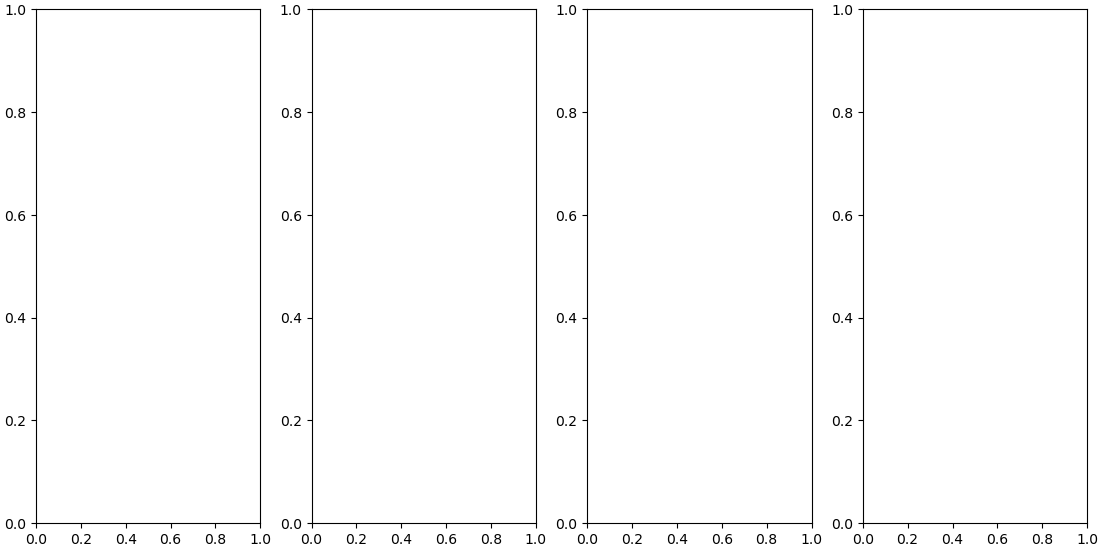

Output()

cosmic_rays = {'cosmic_rays_remove_cosmic_rays': True, 'cosmic_rays_cosmic_rays_contrast_ratio': 8, 'cosmic_rays_cosmic_rays_nrows2bin': 2, 'cosmic_rays_cosmic_rays_median_filter_window': 100, 'cosmic_rays_cosmic_rays_moving_average_window': 20, 'cosmic_rays_cosmic_rays_minimum_intensity': 1000, 'cosmic_rays_cosmic_rays_minimum_average': 600}


In [2]:
scan = 492816
frame = 0
slope = -0.02021732
cosmic_rays = dict(remove_cosmic_rays=True,
                   cosmic_rays_contrast_ratio=8, cosmic_rays_nrows2bin=2, cosmic_rays_median_filter_window=100,
                   cosmic_rays_moving_average_window=20, cosmic_rays_minimum_intensity=1000, cosmic_rays_minimum_average=600)

_ = i21.quick_cosmic_rays(scan=scan, slope=slope, frame=frame, show=True, **cosmic_rays)

# 2a. SGM pitch optimization

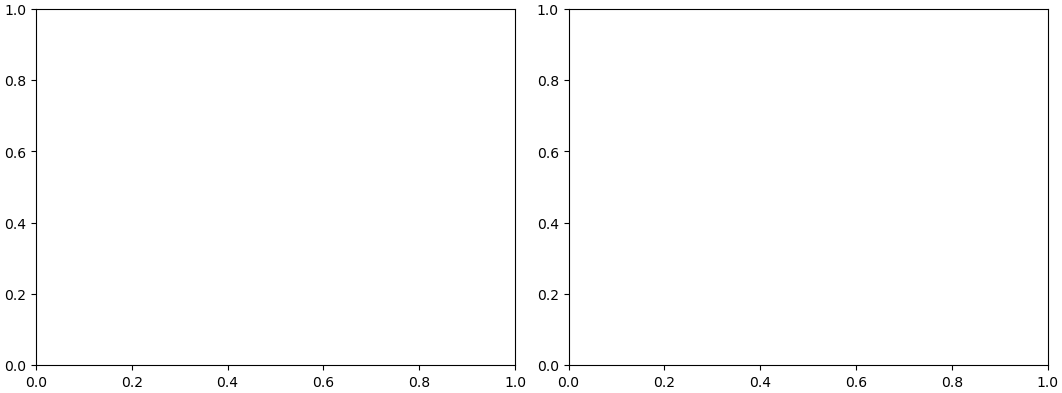

Output()

In [4]:
scans = np.concatenate([np.arange(492812, 492824+1), np.arange(492826, 492833+1)])
dark  = 492825
metadata = ('instrument', 'sgmpitch')
show = True

slope = dict(nbins=4, y_start=300, y_stop=800, floor_y_limits=None, show_curvature=False)
cosmic_rays = dict(remove_cosmic_rays=True,
                   cosmic_rays_contrast_ratio=8, cosmic_rays_nrows2bin=2, cosmic_rays_median_filter_window=100,
                   cosmic_rays_moving_average_window=20, cosmic_rays_minimum_intensity=1000, cosmic_rays_minimum_average=600)

i21.quick_optimization_with_curvature_correction(scans=scans, dark=dark, metadata=metadata, show=show, **slope, **cosmic_rays)



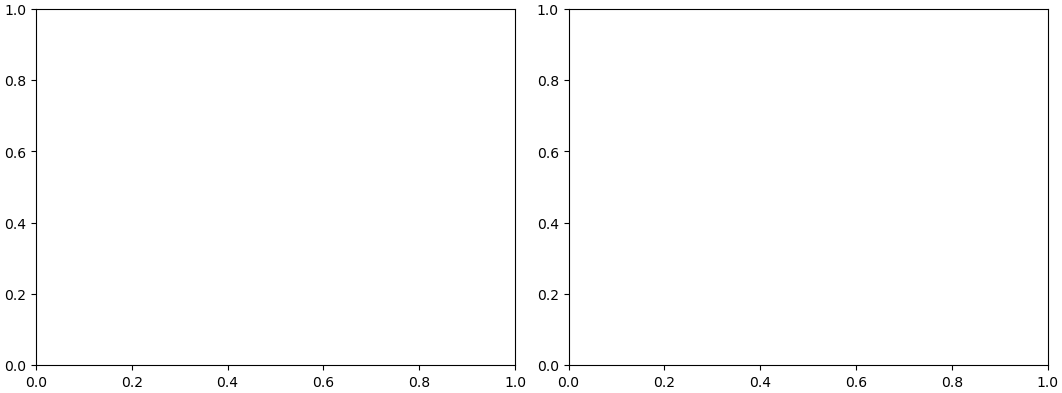

Output()

In [5]:
scans = np.concatenate([np.arange(492812, 492824+1), np.arange(492826, 492833+1)])
dark  = 492825
metadata = ('instrument', 'sgmpitch')
show = True

slope = dict(nbins=4, y_start=300, y_stop=800, floor_y_limits=None, show_curvature=False)
cosmic_rays = dict(remove_cosmic_rays=True,
                   cosmic_rays_contrast_ratio=8, cosmic_rays_nrows2bin=2, cosmic_rays_median_filter_window=100,
                   cosmic_rays_moving_average_window=20, cosmic_rays_minimum_intensity=1000, cosmic_rays_minimum_average=600)

i21.quick_optimization_with_curvature_correction(scans=scans, dark=dark, metadata=metadata, show=show, **slope, **cosmic_rays)



# 2b. CFF optimization

In [9]:
scans = np.concatenate([np.arange(492812, 492824+1), np.arange(492826, 492833+1)])
dark  = 492825
metadata = ('instrument', 'cff')
show = True

slope = dict(nbins=4, y_start=300, y_stop=800, floor_y_limits=None, show_curvature=False)
cosmic_rays = dict(remove_cosmic_rays=True,
                   cosmic_rays_contrast_ratio=8, cosmic_rays_nrows2bin=2, cosmic_rays_median_filter_window=100,
                   cosmic_rays_moving_average_window=20, cosmic_rays_minimum_intensity=1000, cosmic_rays_minimum_average=600)

i21.quick_optimization_with_curvature_correction(scans=scans, dark=dark, metadata=metadata, show=show, **slope, **cosmic_rays)


21

# 3. Calibration

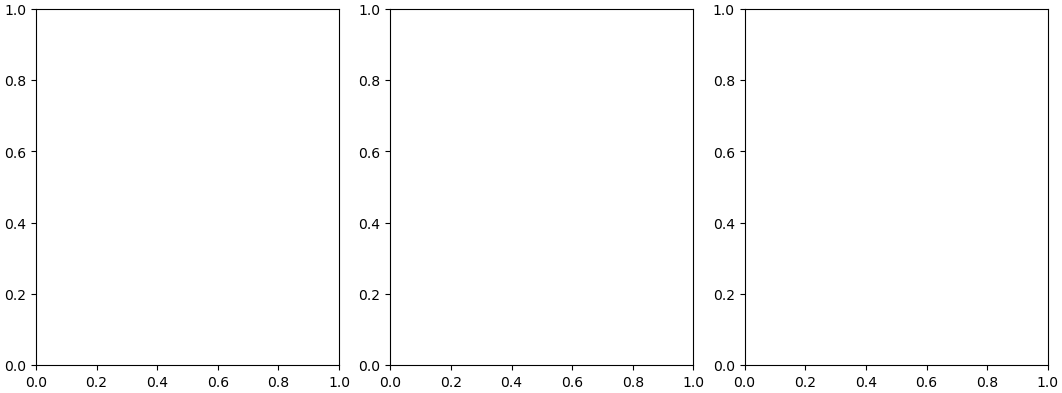

Output()

calib = 0.03377403130811522
slope = -0.019620736269933475


In [2]:
scan = 492849
dark = 492825
show = True

slope = dict(nbins=4, y_start=300, y_stop=800, floor_y_limits=None, show_curvature=False)
cosmic_rays = dict(remove_cosmic_rays=False)

data = i21.quick_calibration_with_curvature_correction(scan=scan, dark=dark, show=show, **slope, **cosmic_rays)

print(f'calib = {data['calib']}')
print(f'slope = {data['slope']}')
print(f'# resolution: {round(data['fwhm']*1000, 0)} meV')

In [ ]:
calib = 0.03377403130811522
slope = -0.019620736269933475
# resolution: 268 meV